# Running quantum circuits on Lagrange and IBM Cloud: Hello World!

## Installing necessary packages

Before we begin, you will need to install some prerequisites into your environment.

Locally, it is necessary to create a conda environment as following
```
conda create -n iqm4_4 python=3.12 ipykernel jupyter
```

Note on Colab:
This notebook can be executed as-is within [Google Colab](https://colab.research.google.com/).

Google Colab provides temporary virtual machines with a standard CPU runtime and standard system memory on the free tier
Hardware availability and limits can change dynamically, so notebooks should not depend on a particular configuration.

Notebook files are normally retained in Google Drive, but the execution environment is temporary. The VM’s local files, installed packages, variables, and process state are lost when the VM is deleted or replaced. Therefore, installation and setup commands should remain in reproducible notebook cells.

Idle runtimes are disconnected and eventually deleted. Google does not publish a fixed idle-time threshold because it varies with availability and usage. Free-tier notebooks can run for at most 12 hours, but may terminate earlier.
Important results should be saved to Drive or external storage.


Run the cell below to complete the installations of the dependencies.

In [ ]:
%pip install uv --quiet
!uv pip install --quiet \
    "qiskit==2.1.2" \
    "qiskit-aer==0.17.2" \
    "qiskit-ibm-runtime==0.45.1" \
    "iqm-client[qiskit]==34.0.3" \
    matplotlib

!uv pip install lagrangeclient --index-url https://gitlab.linksfoundation.com/api/v4/projects/1709/packages/pypi/simple

## Importing both IBM and IQM providers and setting the backends



In [ ]:
# IQM Lagrange
from iqm.qiskit_iqm import IQMProvider

# IBM
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# Generci
from qiskit import transpile
import os

print("IQM and IBM imports successful")

### Lagrange IQM backend

![Lagrange status](https://status.quantum.linksfoundation.com/badge/_/status?labelColor=&color=&style=for-the-badge&label=Lagrange%20Status)

Get the Lagrange IQM token using the authentication client. Visit the generated URL and insert your credentials after clicking on "LINKS Gitlab"

<p align="center">
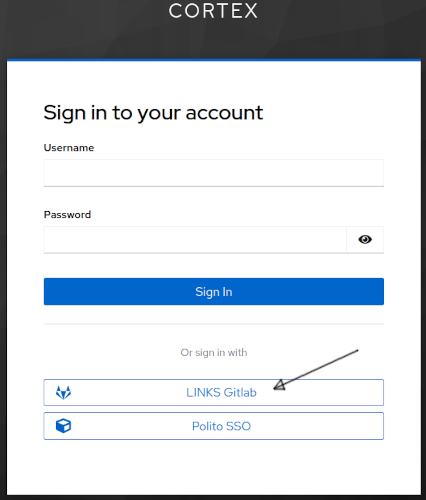
</p>

In [ ]:
!lagrangeclient

## On Windows use the following command instead:
# import sys
# !{sys.executable} -m lagrangeclient

Create an IQM backend and define the executor of circuits on Lagrange.  **DO NOT SHARE THE TOKEN**

In [ ]:
os.environ["IQM_TOKENS_FILE"] = "./tokens.json"

iqm_url = "https://spark.quantum.linksfoundation.com/"
quantum_computer = "default"

lagrange_provider = IQMProvider(iqm_url,quantum_computer=quantum_computer)
lagrange_backend = lagrange_provider.get_backend()

# Here we take a circuit, transpile it for Lagrange,
# set the IQM sampler, execute the circuit and get measurements
def run_counts_lagrange(circuit, shots=1024):
    """Transpile and execute a circuit on Lagrange."""
    transpiled_circuit = transpile(circuit, backend=lagrange_backend)

    # IQM/Lagrange-specific accounting metadata.
    transpiled_circuit.metadata["project"] = "2026_INRIM_QuantumSchool"

    job = lagrange_backend.run([transpiled_circuit], shots=shots)
    print(f"Lagrange job ID: {job.job_id()}", flush=True)

    counts = job.result().get_counts()

    return transpiled_circuit, job, counts

### IBM backend

Log in on [quantum.cloud.ibm.com](https://quantum.cloud.ibm.com)

Create, once, your IBM_QUANTUM_API_KEY from the "API key" menu

Look for the CRN of your personal instance "rpmbt23school-YOUR-USERNAME" and use it as IBM_QUANTUM_INSTANCE

<p align="center">
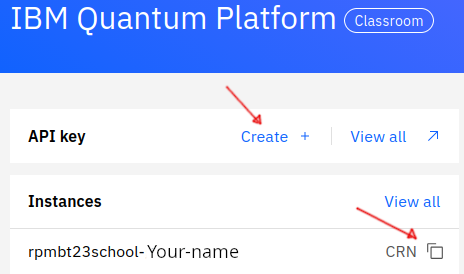
</p>


Store IBM_QUANTUM_API_KEY and IBM_QUANTUM_INSTANCE outside the notebook. **DO NOT SHARE THEM**

Option 1: locally, in shell environment variables

Option 2: in Colab secrets (created on the left "Secret" menu)

<p align="center">
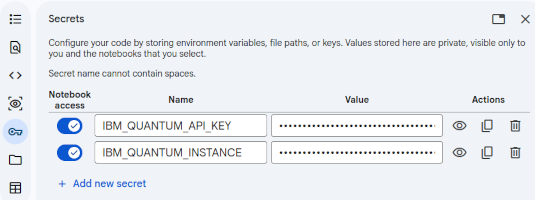
</p>

Create an IBM backend and define the executor of circuits on an accessible IBM machine in the IBM quantum classroom

In [ ]:
from qiskit_ibm_runtime import (QiskitRuntimeService, SamplerV2 as Sampler)

# Get the IBM_QUANTUM_API_KEY and IBM_QUANTUM_INSTANCE variables

# Option 1
#ibm_api_key = os.environ["IBM_QUANTUM_API_KEY"]
#ibm_instance = os.environ["IBM_QUANTUM_INSTANCE"]

# Option 2
from google.colab import userdata
ibm_api_key = userdata.get("IBM_QUANTUM_API_KEY")
ibm_instance = userdata.get("IBM_QUANTUM_INSTANCE")

ibm_service = QiskitRuntimeService(
    token=ibm_api_key,
    #instance=ibm_instance # In case you have access to multiple instances,
                            # set the chosen one here
)

print("Accessible instances:")
for instance in ibm_service.instances():
    print(instance)

print("\nAccessible operational QPUs:")
for available_backend in ibm_service.backends(operational=True,simulator=False):
    print(available_backend.name)

# Automatically select an operational QPU
ibm_backend = ibm_service.least_busy(operational=True,simulator=False,min_num_qubits=3)
# Or, select a specific accessible QPU
#ibm_backend_name = os.environ["IBM_QUANTUM_BACKEND"]
#ibm_backend = ibm_service.backend(ibm_backend_name)

# Here we take a generic circuit, transpile it for the IBM machine,
# set the IBM sampler, execute the circuit and get measurements
def run_counts_ibm(circuit, shots=1024):
    """Transpile and execute a measured circuit on IBM Quantum."""
    transpiled_circuit = transpile(circuit, backend=ibm_backend)

    # mode=backend means ordinary job mode, not a Runtime session.
    ibm_sampler = Sampler(mode=ibm_backend)
    job = ibm_sampler.run([transpiled_circuit], shots=shots)
    print(f"IBM job ID: {job.job_id()}", flush=True)

    pub_result = job.result()[0]

    # measure_all() creates a classical register called "meas".
    counts = pub_result.data.meas.get_counts()

    return transpiled_circuit, job, counts

### Wrapper

In [ ]:
def run_counts(circuit, backend_name, shots=1024):
    backend_name = backend_name.lower()

    if backend_name == "lagrange":
        transpiled, job, counts = run_counts_lagrange(circuit,shots=shots)

    elif backend_name == "ibm":
        transpiled, job, counts = run_counts_ibm(circuit,shots=shots)

    else:
        raise ValueError("backend_name must be either 'lagrange' or 'ibm'")

    return {
        "backend": backend_name,
        "job_id": job.job_id(),
        "shots": shots,
        "counts": counts,
        "transpiled_circuit": transpiled,
        "job": job,
    }

## Circuit, job, and analysis (backend-independent)

Create a basic circuit

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

circuit = QuantumCircuit(3)
circuit.h(0)
circuit.cx(0, 1)
circuit.cx(0, 2)
circuit.measure_all()

print(circuit.draw(output='text'))

Run the circuit on one or both backends (Lagrange should be more available)

In [ ]:
lagrange_result = run_counts(circuit, backend_name="lagrange",shots=1024)
print("Lagrange job:", lagrange_result["job_id"])
print("Lagrange counts:", lagrange_result["counts"])

In [ ]:
ibm_result = run_counts(circuit, backend_name="ibm",shots=1024)
print("IBM job:", ibm_result["job_id"])
print("IBM counts:", ibm_result["counts"])

In [ ]:
plot_histogram(
    [
        lagrange_result["counts"],
        ibm_result["counts"],
    ],
    legend=["IQM Lagrange", "IBM"],
)